In [2]:
import os 

os.getcwd()
os.chdir("../")

In [ ]:
os.getcwd()

'c:\\Users\\Jovch\\Omnibus_Rebus\\Projects\\JobMarketIntelligence'

In [5]:
import pandas as pd
import json 

path = "data.json"
df = pd.read_json(path)

print(df.head())
print(df.shape)
print(df.info())

                                           job_title  \
0               Wireless Systems Validation Engineer   
1                            PHY RTL Design Engineer   
2  Site Reliability Engineer, Enterprise Technolo...   
3                    Enclosure Global Supply Manager   
4  Early Career -  Power/EMIR Design Engineer (M,...   

                               location            experience  \
0  Sunnyvale, California, United States                    10   
1  Sunnyvale, California, United States  No Experience Nedded   
2  Sunnyvale, California, United States                     5   
3             Shanghai, Shanghai, China  No Experience Nedded   
4       Munich, Bavaria-Bayern, Germany  No Experience Nedded   

                education                     industry  
0         [Master's, PhD]                     Hardware  
1                      []                     Hardware  
2  [Bachelor's, Master's]        Software and Services  
3                      []  Operations and Su

In [12]:
#Convert empty lists to None
df = df.map(
    lambda x: None if x == [] or (isinstance(x,str) and x.strip() == "" ) else x
)

#Convert all strings to lowercase and strip whitespace
df = df.map(
    lambda x: x.strip().lower() if isinstance(x,str) else x
)

#No experience neede to 0 
df["experience"] = df["experience"].apply(
    lambda x: 0 if isinstance(x, str) and "no experience" in x.lower() else x
)

#Remove duplicates
duplicate_check = df.map(
    lambda x: tuple(x) if isinstance(x, list) else x
)


df = df.loc[
    ~duplicate_check.duplicated()
].reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")
print(f"Duplicates remaining: {df.map(lambda x: tuple(x) if isinstance(x, list) else x).duplicated().sum()}")

display(df.head())

Rows after cleaning: 5633
Duplicates remaining: 0


,job_title,location,experience,education,industry
0,wireless systems validation engineer,"sunnyvale, california, united states",10,"[Master's, PhD]",hardware
1,phy rtl design engineer,"sunnyvale, california, united states",0,None,hardware
2,"site reliability engineer, enterprise technolo...","sunnyvale, california, united states",5,"[Bachelor's, Master's]",software and services
3,enclosure global supply manager,"shanghai, shanghai, china",0,None,operations and supply chain
4,"early career - power/emir design engineer (m,...","munich, bavaria-bayern, germany",0,None,hardware


In [14]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")

print("\nDuplicate job titles:")
print(df["job_title"].duplicated().sum())

Rows: 5633
Columns: 5

Missing values:
job_title        0
location         0
experience       0
education     3170
industry         0
dtype: int64

Duplicate rows:

Duplicate job titles:
2120


In [17]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.3 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 28.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 22.3 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Total Jobs Analyzed: 5,633
industry
hardware                          2257
software and services             1404
corporate functions                399
operations and supply chain        398
machine learning and ai            395
apple retail                       337
sales and business development     194
marketing                          158
design                              37
students                            31
support and service                 23
Name: count, dtype: int64
industry
hardware                          40.07
software and services             24.92
corporate functions                7.08
operations and supply chain        7.07
machine learning and ai            7.01
apple retail                       5.98
sales and business development     3.44
marketing                          2.80
design                             0.66
students                           0.55
support and service                0.41
Name: proportion, dtype: float64


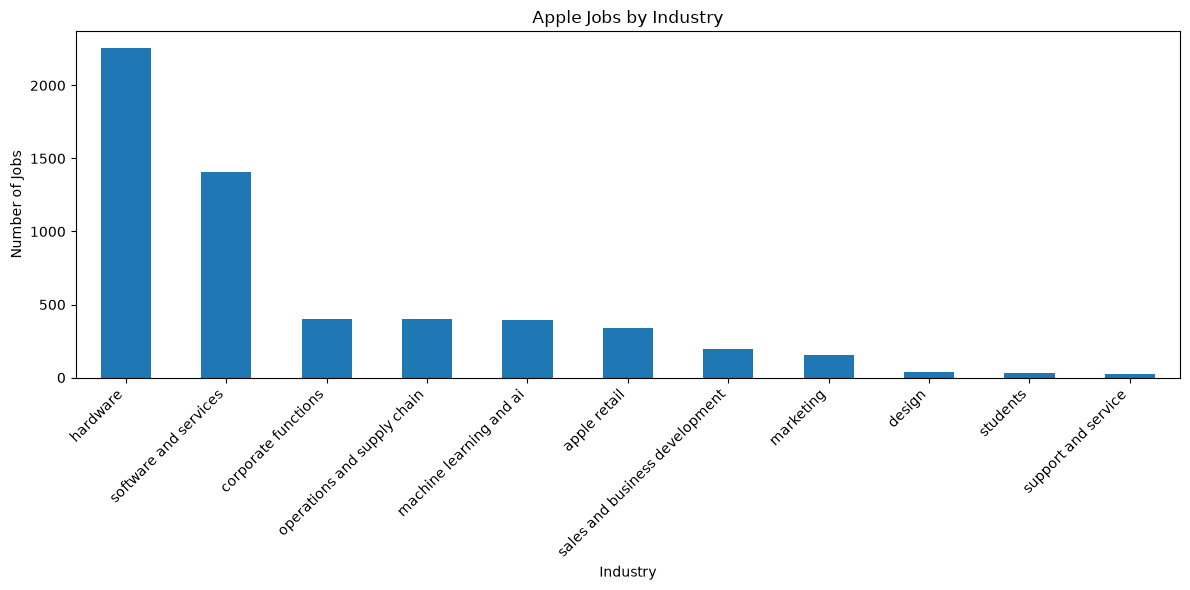

In [18]:
import matplotlib.pyplot as plt


total_jobs = len(df)
print(f"Total Jobs Analyzed: {total_jobs:,}")

industry_counts = df["industry"].value_counts()
print(industry_counts)

industry_percentage = (
    df["industry"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(industry_percentage)

plt.figure(figsize=(12, 6))

industry_counts.plot(kind="bar")

plt.title("Apple Jobs by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

location
cupertino, california, united states                 1364
austin, texas, united states                          546
sunnyvale, california, united states                  384
san diego, california, united states                  379
shanghai, shanghai, china                             245
seattle, washington, united states                    239
san francisco bay area, california, united states     201
santa clara, california, united states                194
beaverton, oregon, united states                      119
singapore, singapore                                   96
culver city, california, united states                 93
london, england, united kingdom                        84
bengaluru, karnataka, india                            76
shenzhen, guangdong, china                             72
san jose, california, united states                    69
herzliya, tel aviv district, israel                    68
hyderabad, telangana, india                            61
munic

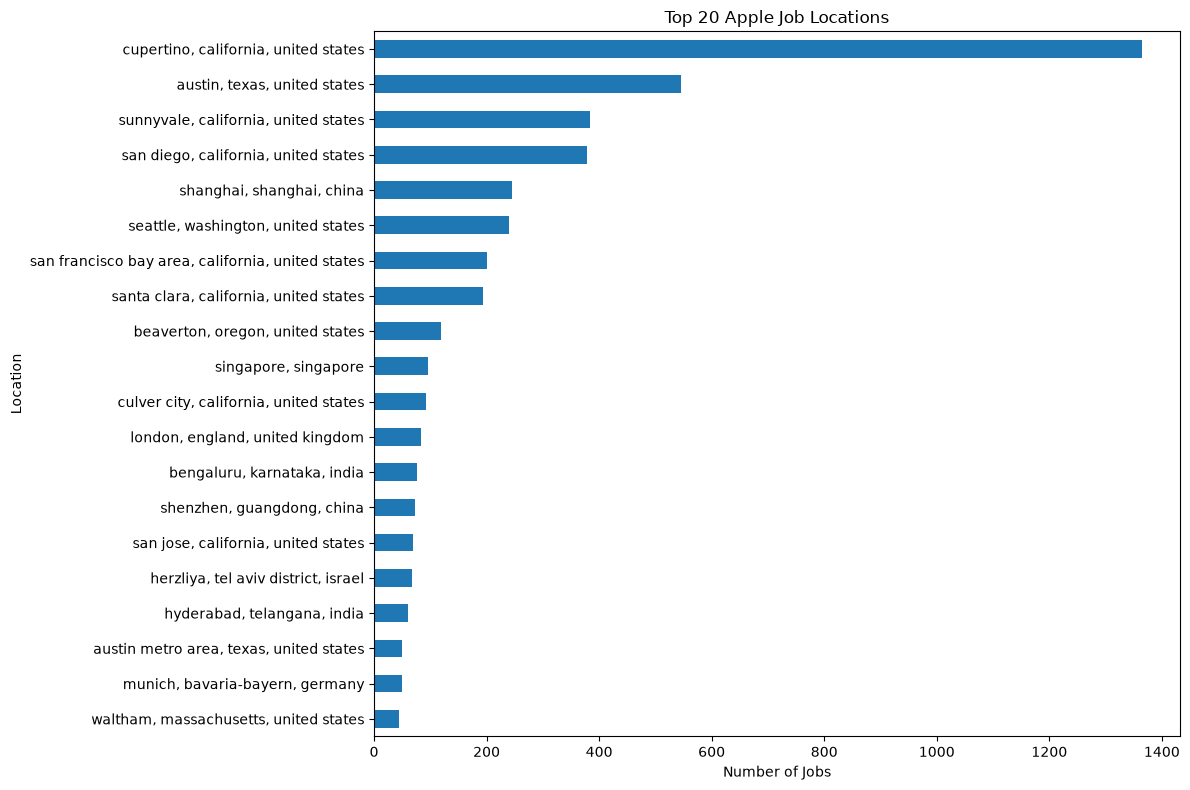

In [19]:
#Location distribution
location_counts = df["location"].value_counts()
print(location_counts.head(20))

plt.figure(figsize=(12, 8))
location_counts.head(20).sort_values().plot(
    kind="barh"
)
plt.title("Top 20 Apple Job Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

industry                                 apple retail  corporate functions  \
location                                                                     
aachen, north rhine-westphalia, germany             0                    0   
adelaide, south australia, australia                0                    0   
ahmedabad, gujarat, india                           0                    0   
akron, ohio, united states                          1                    0   
albany, new york, united states                     1                    0   
...                                               ...                  ...   
xi'an, shaanxi, china                              15                    0   
yokohama, kanagawa-ken, japan                       3                    1   
zaragoza, zaragoza, spain                           1                    0   
zhengzhou, henan, china                             0                    0   
zurich, zurich, switzerland                         0           

industry,apple retail,corporate functions,design,hardware,machine learning and ai,marketing,operations and supply chain,sales and business development,software and services,students,support and service
location,,,,,,,,,,,
"austin, texas, united states",1,65,0,305,11,2,36,8,116,1,1
"beaverton, oregon, united states",0,0,0,118,0,0,0,0,1,0,0
"bengaluru, karnataka, india",0,3,0,10,3,0,30,1,29,0,0
"culver city, california, united states",0,18,9,2,1,35,0,1,27,0,0
"cupertino, california, united states",1,116,19,476,139,53,106,26,427,1,0
"london, england, united kingdom",0,6,1,31,4,12,0,3,27,0,0
"san diego, california, united states",0,4,0,251,8,0,1,3,112,0,0
"san francisco bay area, california, united states",2,1,2,142,10,0,6,3,34,0,1
"san jose, california, united states",0,10,0,56,0,0,0,1,2,0,0


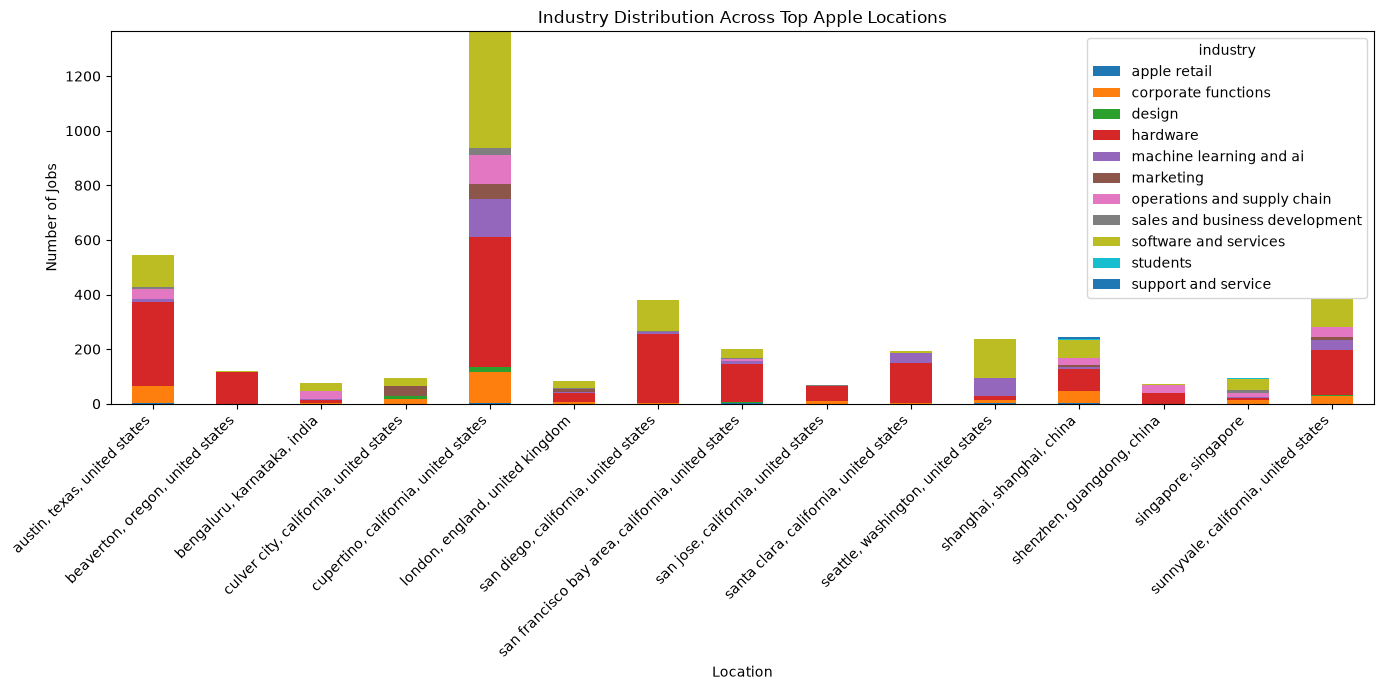

In [20]:
#Industry x location 
industry_location = pd.crosstab(
    df["location"],
    df["industry"]
)
print(industry_location)

top_locations = df["location"].value_counts().head(15).index

location_industry = pd.crosstab(
    df[df["location"].isin(top_locations)]["location"],
    df[df["location"].isin(top_locations)]["industry"]
)

display(location_industry)

location_industry.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Industry Distribution Across Top Apple Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Mean: 4.778270903603763
Median: 4.0
Minimum: 0
Maximum: 20


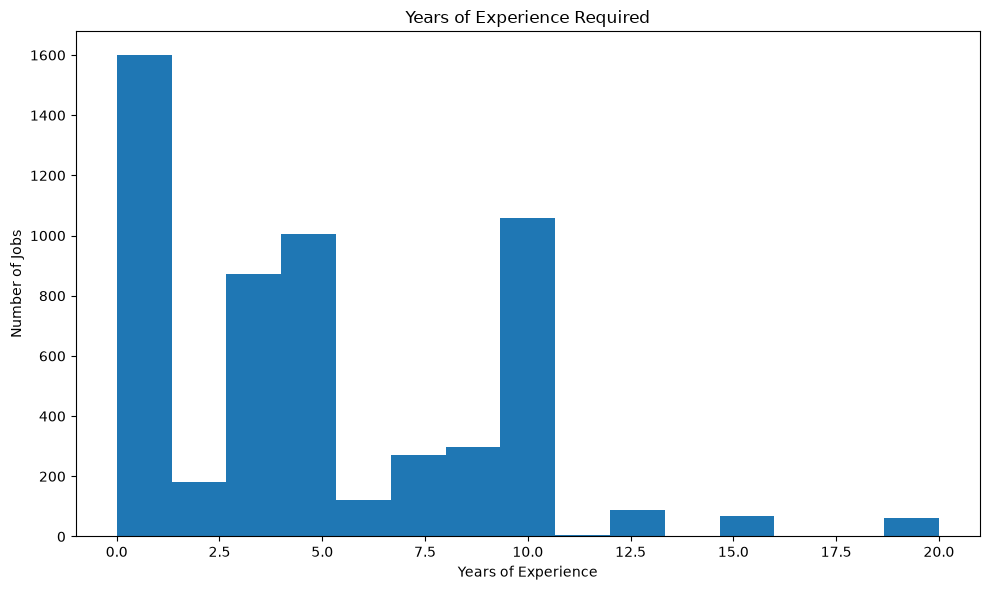

In [22]:
#Experience analysis
print("Mean:", df["experience"].mean())
print("Median:", df["experience"].median())
print("Minimum:", df["experience"].min())
print("Maximum:", df["experience"].max())

plt.figure(figsize=(10, 6))

df["experience"].dropna().plot(
    kind="hist",
    bins=15
)

plt.title("Years of Experience Required")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Jobs")

plt.tight_layout()
plt.show()

experience_category
3-5 Years        1876
6-10 Years       1745
No Experience    1578
10+ Years         231
1-2 Years         203
Name: count, dtype: int64


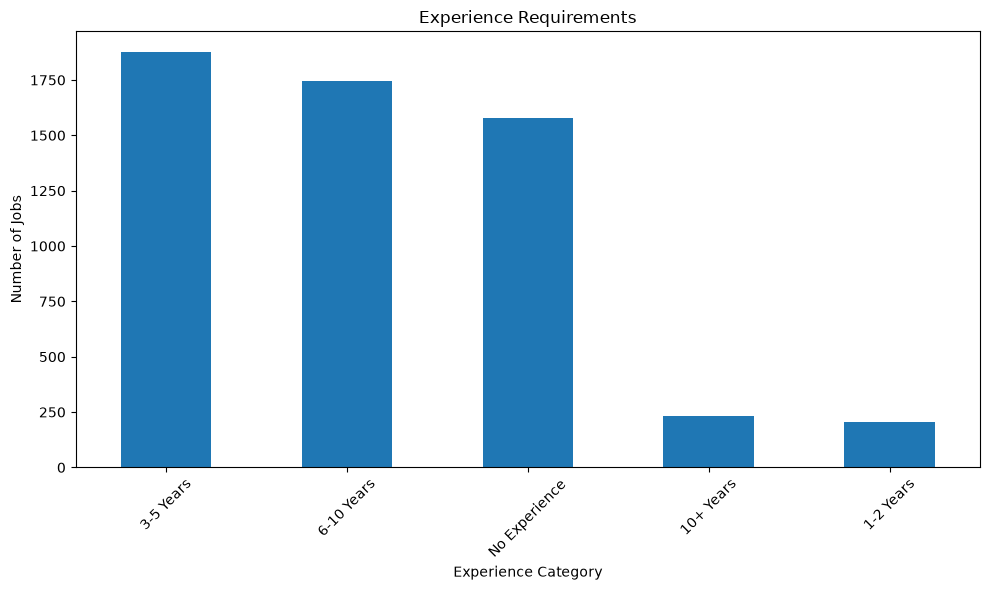

In [23]:
def experience_category(x):

    if pd.isna(x):
        return "Not Specified"

    if x == 0:
        return "No Experience"

    if x <= 2:
        return "1-2 Years"

    if x <= 5:
        return "3-5 Years"

    if x <= 10:
        return "6-10 Years"

    return "10+ Years"


df["experience_category"] = df["experience"].apply(
    experience_category
)

experience_categories = df["experience_category"].value_counts()

print(experience_categories)

plt.figure(figsize=(10, 6))

experience_categories.plot(kind="bar")

plt.title("Experience Requirements")
plt.xlabel("Experience Category")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,count,mean,median,min,max
industry,,,,,
corporate functions,399,6.543860,7.0,0,15
marketing,158,7.424051,7.0,0,18
design,37,6.162162,5.0,0,12
support and service,23,4.739130,5.0,0,12
operations and supply chain,398,4.643216,5.0,0,20
software and services,1404,4.458689,5.0,0,18
hardware,2257,5.374391,3.0,0,20
sales and business development,194,4.912371,3.0,0,20
machine learning and ai,395,3.577215,3.0,0,20


<Figure size 1200x700 with 0 Axes>

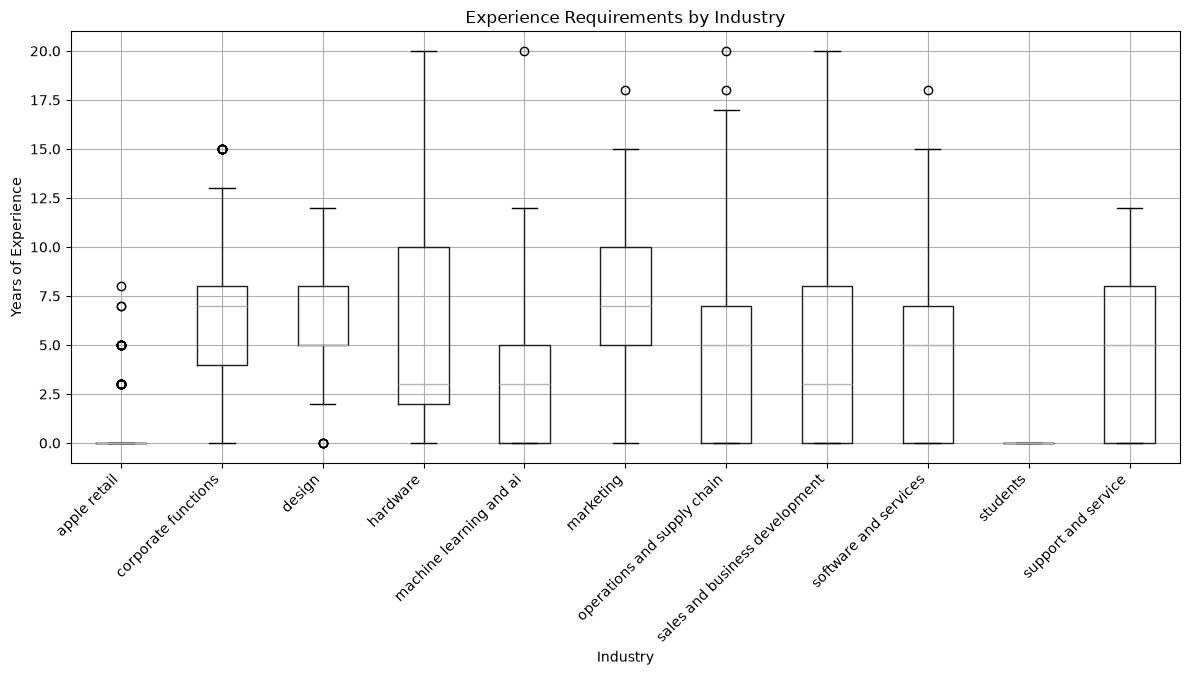

In [24]:
experience_by_industry = (
    df.groupby("industry")["experience"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .sort_values("median", ascending=False)
)

display(experience_by_industry)

plt.figure(figsize=(12, 7))

df.boxplot(
    column="experience",
    by="industry",
    figsize=(12, 7)
)

plt.title("Experience Requirements by Industry")
plt.suptitle("")
plt.xlabel("Industry")
plt.ylabel("Years of Experience")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

education
Bachelor's     1448
PhD             955
Master's        611
MS              148
BS              144
Associate's      17
BA                8
Doctorate         3
Name: count, dtype: int64


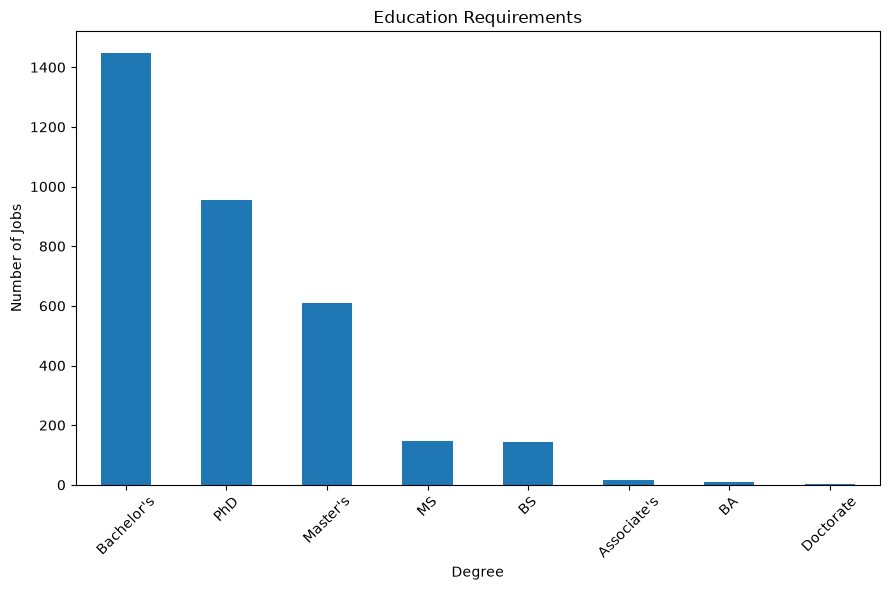

In [25]:
#Education analysis 
degrees = [
    "bachelor's",
    "master's",
    "phd",
    "doctorate",
    "associate's",
    "bs",
    "ms",
    "ba",
    "ma",
    "as",
    "aa"
]

for degree in degrees:

    column_name = degree.replace("'", "").replace(" ", "_")

    df[column_name] = df["education"].apply(
        lambda x: degree in x if isinstance(x, list) else False
    )

education_df = df.explode("education")

education_counts = (
    education_df["education"]
    .dropna()
    .value_counts()
)

print(education_counts)


plt.figure(figsize=(9, 6))

education_counts.plot(kind="bar")

plt.title("Education Requirements")
plt.xlabel("Degree")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df["education_required"] = df["education"].notna()

education_requirement = df["education_required"].value_counts()

print(education_requirement)

education_required
False    3170
True     2463
Name: count, dtype: int64


education_required,False,True
industry,,
apple retail,100.00,0.00
corporate functions,61.90,38.10
design,78.38,21.62
hardware,57.47,42.53
machine learning and ai,21.77,78.23
marketing,68.35,31.65
operations and supply chain,55.03,44.97
sales and business development,57.22,42.78
software and services,50.28,49.72


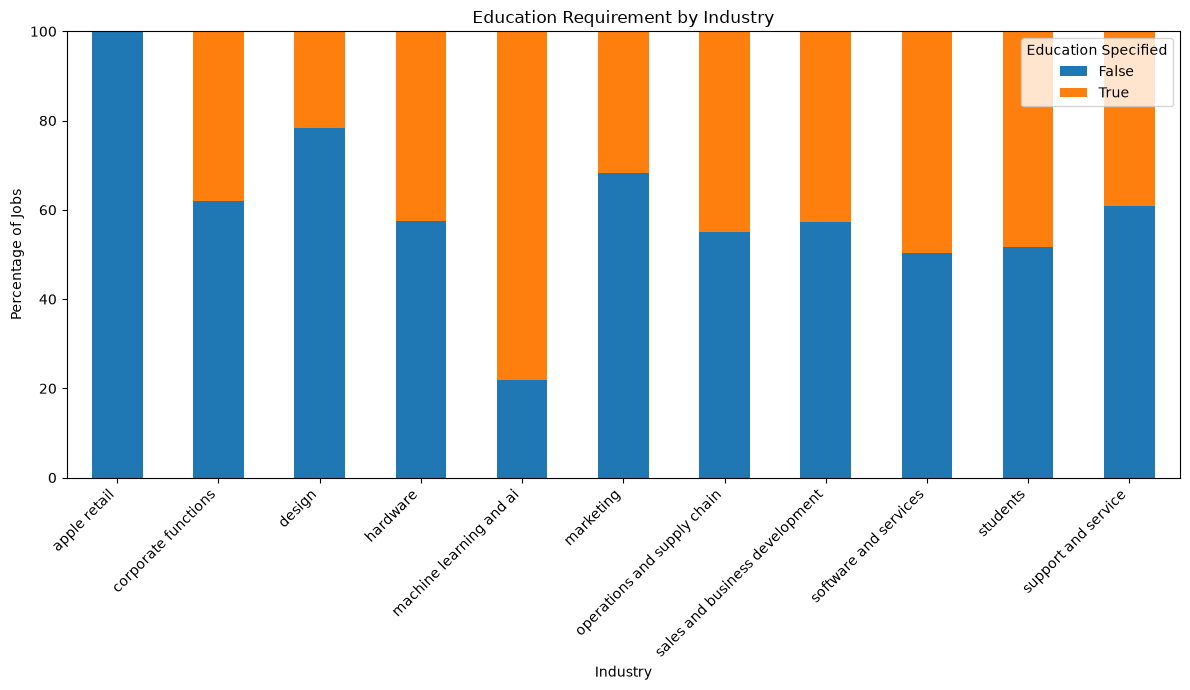

In [29]:
#Education x industry 
education_industry = pd.crosstab(
    df["industry"],
    df["education_required"],
    normalize="index"
) * 100

display(education_industry.round(2))

education_industry.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Education Requirement by Industry")
plt.xlabel("Industry")
plt.ylabel("Percentage of Jobs")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Education Specified")

plt.tight_layout()
plt.show()